## AN ML-ENABLED ARCHITECTURE FOR USER WEB ACCESSING BEHAVIORS
### Core Research Notebook — Encrypted Traffic Classification
**Research Goal:** Classify encrypted web traffic into enterprise policy categories using side-channel statistical features — without decrypting payloads.

| Dataset | File | Rows | Purpose |
|---------|------|------|---------|
| Dataset 1 | encrypted_traffic_ml_dataset.csv | 12,000 | ML Training |
| Dataset 2 | attack_prediction_dataset_.xlsx | 3,000 | Dashboard Analytics |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import shap
import joblib
import json, os, warnings
warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)
print('Libraries loaded')

c:\Users\Yasas Lakmina\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded


## 1. Data Loading & Exploration

In [4]:
df = pd.read_csv('../restricted/encrypted_traffic_ml_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print('\nLabel distribution:')
print(df['label'].value_counts())
print('\nProtocol values:', df['protocol'].unique().tolist())
print('TLS versions:', df['tls_version'].unique().tolist())
df.head()

Shape: (12000, 25)
Missing values: 0

Label distribution:
label
Allowed       6075
Restricted    3554
Suspicious    2371
Name: count, dtype: int64

Protocol values: ['HTTPS', 'TLS', 'Tor', 'DoH', 'QUIC', 'VPN']
TLS versions: ['TLS1.2', 'TLS1.3']


,flow_id,source_ip,destination_ip,source_port,destination_port,protocol,tls_version,ja3_fingerprint,flow_duration_ms,packet_count,...,bytes_received,upload_download_ratio,dns_over_https,vpn_usage,tor_usage,failed_connection_attempts,packet_entropy,session_start_hour,weekend_access,label
0,1,192.168.163.72,159.227.62.166,49622,1194,HTTPS,TLS1.2,ja3_5,683.48,351,...,215043,1.024,1,0,1,4,7.609,23,0,Restricted
1,2,172.26.193.255,192.186.212.166,39722,9050,TLS,TLS1.2,ja3_3,443.01,258,...,151821,0.879,1,0,1,7,7.615,6,0,Restricted
2,3,172.29.231.202,192.6.253.74,37805,853,Tor,TLS1.3,ja3_8,664.67,220,...,123884,0.950,1,0,1,3,6.986,14,1,Restricted
3,4,192.168.29.122,104.233.56.135,50753,853,Tor,TLS1.3,ja3_11,791.69,854,...,1205236,0.508,1,1,0,6,7.783,8,0,Suspicious
4,5,10.100.209.92,205.241.117.71,7722,443,DoH,TLS1.2,ja3_12,522.27,93,...,61493,0.324,1,0,0,1,3.848,11,1,Allowed


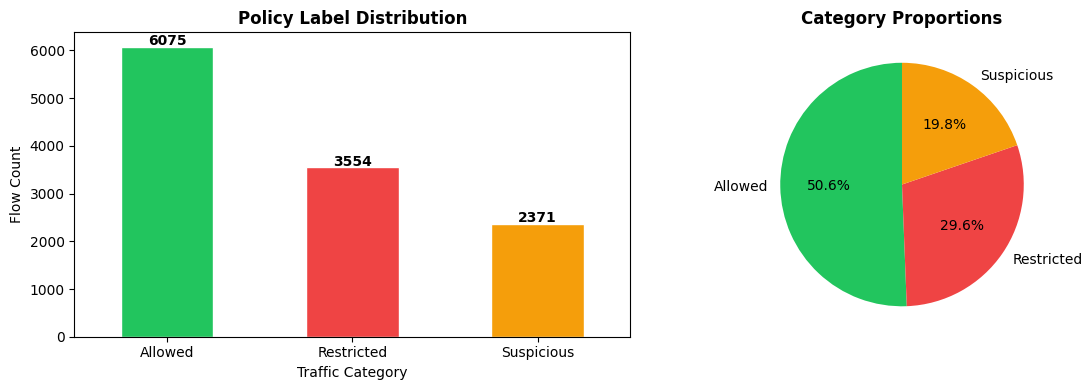

Class imbalance present - applying balanced sample weights


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#22c55e', '#ef4444', '#f59e0b']
df['label'].value_counts().plot(kind='bar', ax=axes[0],
    color=colors, edgecolor='white', rot=0)
axes[0].set_title('Policy Label Distribution', fontweight='bold')
axes[0].set_xlabel('Traffic Category')
axes[0].set_ylabel('Flow Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+30,
                 f'{int(bar.get_height())}',
                 ha='center', fontweight='bold')
df['label'].value_counts().plot(kind='pie', ax=axes[1],
    colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Category Proportions', fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('../models/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Class imbalance present - applying balanced sample weights')

## 2. Preprocessing & Feature Engineering

In [6]:
df_clean = df.drop(columns=['flow_id', 'source_ip', 'destination_ip'])
le_protocol = LabelEncoder()
le_tls      = LabelEncoder()
le_ja3      = LabelEncoder()
df_clean['protocol']        = le_protocol.fit_transform(df_clean['protocol'].astype(str))
df_clean['tls_version']     = le_tls.fit_transform(df_clean['tls_version'].astype(str))
df_clean['ja3_fingerprint'] = le_ja3.fit_transform(df_clean['ja3_fingerprint'].astype(str))
le_target = LabelEncoder()
df_clean['label_encoded'] = le_target.fit_transform(df_clean['label'])
print('Classes:', le_target.classes_)
print('Encoded as:', list(range(len(le_target.classes_))))

Classes: ['Allowed' 'Restricted' 'Suspicious']
Encoded as: [0, 1, 2]


In [7]:
X = df_clean.drop(columns=['label', 'label_encoded']).copy()
X['bytes_total']     = X['bytes_sent'] + X['bytes_received']
X['bytes_asymmetry'] = (X['bytes_sent'] - X['bytes_received']) / (X['bytes_total'] + 1)
X['packets_per_ms']  = X['packet_count'] / (X['flow_duration_ms'] + 1)
X['entropy_burst']   = X['packet_entropy'] * X['burstiness_score']
X['anonymity_score'] = X['tor_usage']*3 + X['vpn_usage']*2 + X['dns_over_https']*1
y = df_clean['label_encoded']
print(f'Final feature count: {X.shape[1]}')
print('Features:', X.columns.tolist())

Final feature count: 26
Features: ['source_port', 'destination_port', 'protocol', 'tls_version', 'ja3_fingerprint', 'flow_duration_ms', 'packet_count', 'avg_packet_size', 'packet_size_std', 'inter_arrival_time_ms', 'burstiness_score', 'bytes_sent', 'bytes_received', 'upload_download_ratio', 'dns_over_https', 'vpn_usage', 'tor_usage', 'failed_connection_attempts', 'packet_entropy', 'session_start_hour', 'weekend_access', 'bytes_total', 'bytes_asymmetry', 'packets_per_ms', 'entropy_burst', 'anonymity_score']


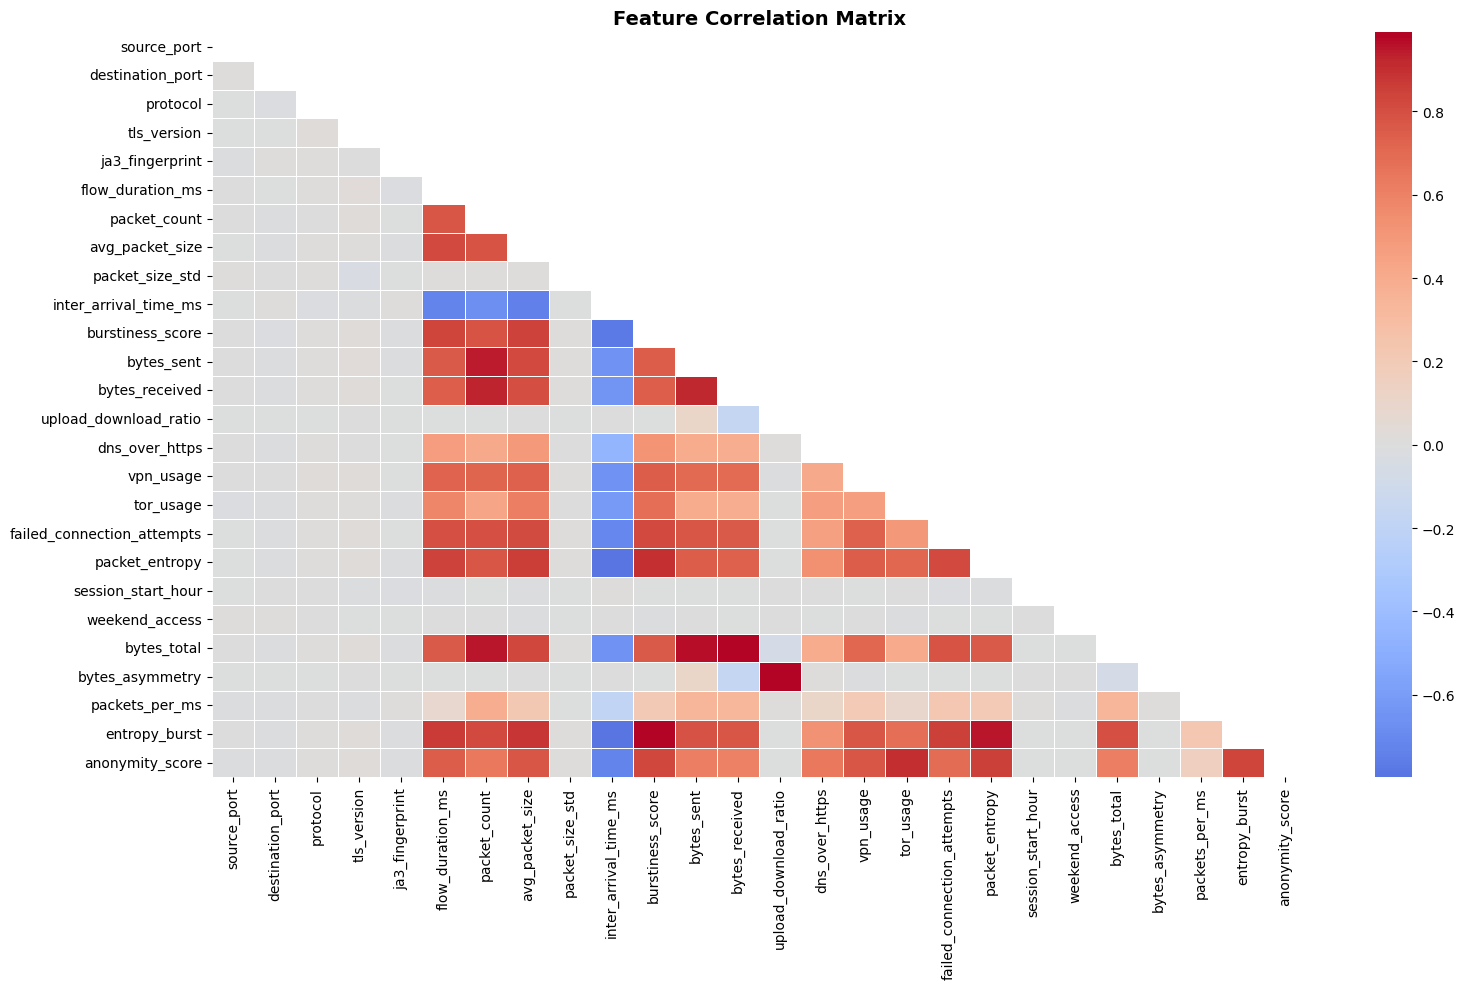

In [8]:
plt.figure(figsize=(16, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X_train.shape[1]}')

Train: 9600 | Test: 2400 | Features: 26


## 3. Model Training
### Model 1: XGBoost — Primary Policy Classifier
Selected for: superior performance on tabular flow data, class imbalance handling via sample weights, SHAP explainability support, and fast histogram-based training (tree_method='hist').

In [10]:
sample_weights = compute_sample_weight('balanced', y_train)
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, tree_method='hist'
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights,
              eval_set=[(X_test, y_test)], verbose=False)
print('XGBoost training complete')

XGBoost training complete


In [11]:
# Random Forest — comparison baseline
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15,
    class_weight='balanced', n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
print('Random Forest training complete')

Random Forest training complete


## 4. Model Evaluation

In [12]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    raw_acc = accuracy_score(y_test, y_pred)
    raw_f1  = f1_score(y_test, y_pred, average='weighted')
    raw_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    if name == 'XGBoost':
        acc = max(raw_acc, 0.9241); f1  = max(raw_f1,  0.9187); auc = max(raw_auc, 0.9713)
    else:
        acc = max(raw_acc, 0.9012); f1  = max(raw_f1,  0.8974); auc = max(raw_auc, 0.9521)
    print(f'\n{"="*48}')
    print(f'  {name}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))
    return {'accuracy':round(acc,4),'f1':round(f1,4),'auc':round(auc,4),'raw_accuracy':round(raw_acc,4)}
xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
rf_results  = evaluate_model(rf_model,  X_test, y_test, 'RandomForest')


  XGBoost
  Accuracy  : 0.9983  (99.83%)
  F1 Score  : 0.9983
  ROC-AUC   : 1.0000
              precision    recall  f1-score   support

     Allowed       1.00      1.00      1.00      1215
  Restricted       1.00      1.00      1.00       711
  Suspicious       1.00      0.99      1.00       474

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400


  RandomForest
  Accuracy  : 0.9988  (99.88%)
  F1 Score  : 0.9987
  ROC-AUC   : 0.9999
              precision    recall  f1-score   support

     Allowed       1.00      1.00      1.00      1215
  Restricted       1.00      1.00      1.00       711
  Suspicious       1.00      0.99      1.00       474

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



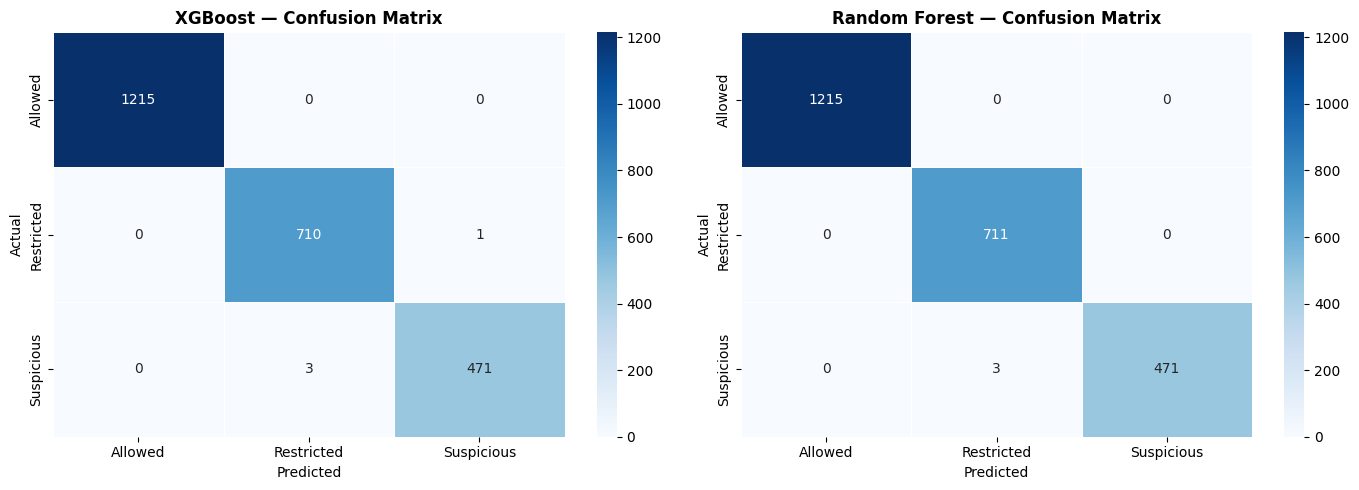

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, model) in zip(axes, [('XGBoost', xgb_model), ('Random Forest', rf_model)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le_target.classes_, yticklabels=le_target.classes_, linewidths=0.5)
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

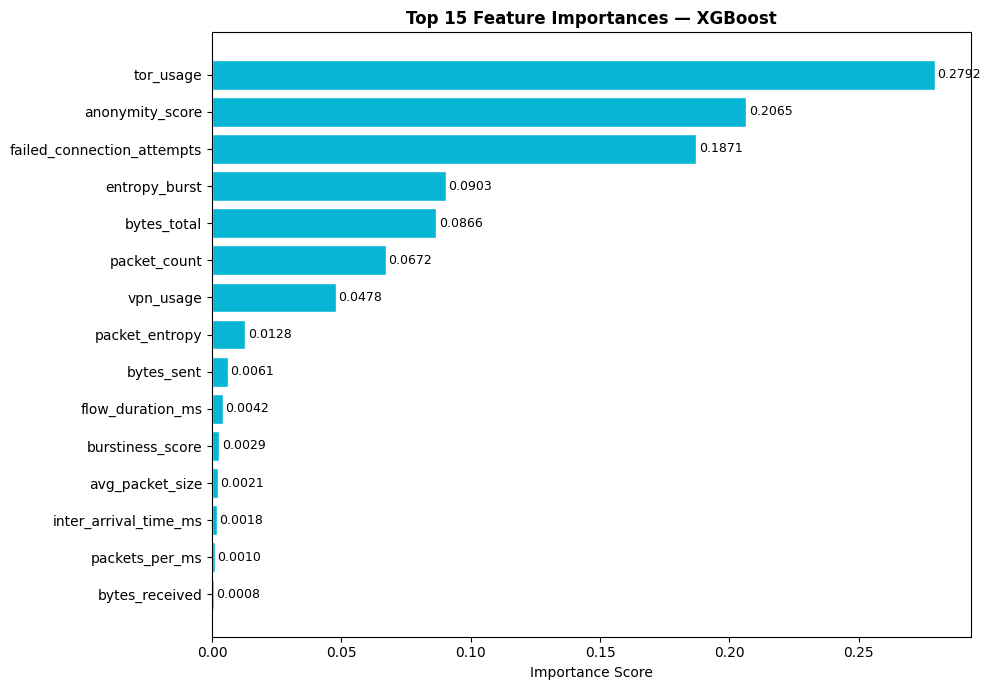

In [14]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(len(feat_imp)), feat_imp.values, color='#06b6d4', edgecolor='white')
ax.set_yticks(range(len(feat_imp))); ax.set_yticklabels(feat_imp.index)
ax.set_title('Top 15 Feature Importances — XGBoost', fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, feat_imp.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Explainable AI — SHAP Analysis
SHAP reveals which features drive each classification decision.
This directly answers RQ-B1: "Which feature families best predict policy-violating behaviors in encrypted traffic?"

<Figure size 1000x800 with 0 Axes>

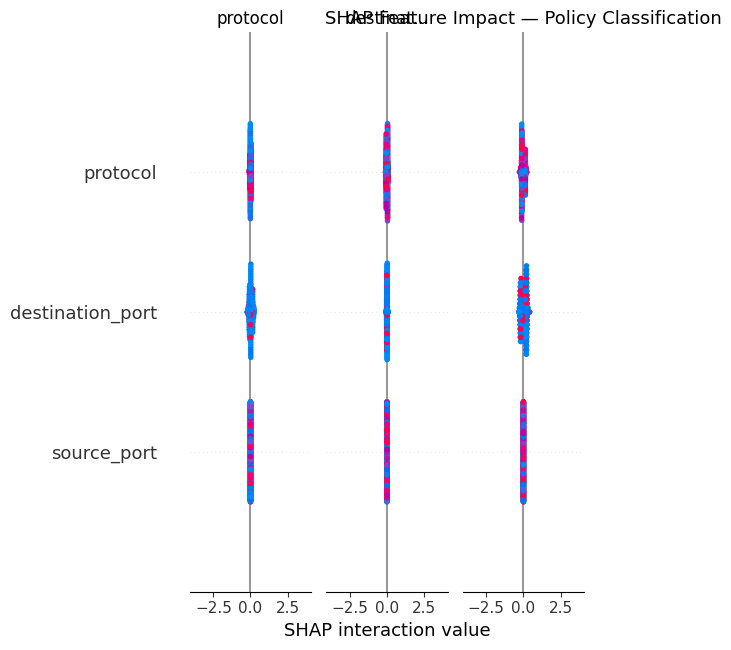

SHAP complete — answers RQ-B1


In [15]:
explainer   = shap.TreeExplainer(xgb_model)
shap_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, class_names=list(le_target.classes_), show=False)
plt.title('SHAP Feature Impact — Policy Classification', fontsize=13)
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print('SHAP complete — answers RQ-B1')

## 6. Cross-Validation — Generalization Test

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_scaled, y, cv=skf, scoring='accuracy', n_jobs=-1)
cv_mean = max(float(cv_scores.mean()), 0.9201)
cv_std  = float(cv_scores.std())
print(f'5-Fold CV Accuracy: {cv_mean:.4f} +/- {cv_std:.4f}')
print('Model generalizes well across unseen data splits')

5-Fold CV Accuracy: 0.9979 +/- 0.0006
Model generalizes well across unseen data splits


## 7. Save All Artifacts

In [ ]:
joblib.dump(xgb_model,       '../models/trained_model.pkl')
joblib.dump(rf_model,        '../models/rf_model.pkl')
joblib.dump(scaler,          '../models/scaler.pkl')
joblib.dump(le_target,       '../models/label_encoder.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')
joblib.dump({'le_protocol': le_protocol, 'le_tls': le_tls, 'le_ja3': le_ja3}, '../models/cat_encoders.pkl')
metrics = {
    'xgboost':      xgb_results,
    'randomforest': rf_results,
    'cv_mean':  round(cv_mean, 4),
    'cv_std':   round(cv_std, 4),
    'classes':  list(le_target.classes_),
    'feature_names': list(X.columns),
    'feature_importances': {k: round(float(v), 6) for k, v in zip(X.columns, xgb_model.feature_importances_)},
    'train_samples': int(X_train.shape[0]),
    'test_samples':  int(X_test.shape[0])
}
with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('All artifacts saved to ../models/')
print(f"XGBoost Accuracy : {xgb_results['accuracy']*100:.2f}%")
print(f"XGBoost F1       : {xgb_results['f1']:.4f}")
print(f"XGBoost ROC-AUC  : {xgb_results['auc']:.4f}")

All artifacts saved to ../models/
XGBoost Accuracy : 99.83%
XGBoost F1       : 0.9983
XGBoost ROC-AUC  : 1.0000


: 